## Multi-protocol CNN Raw CSI Experiments

This notebook runs the fixed-capacity CNN across block, LOVO, and cross-session protocols with one independent run per configured seed.

In [1]:
from __future__ import annotations

import pandas as pd
import torch

from utils.config import (
    ANCHOR_GROUPS,
    ARCHITECTURE,
    BANDS_TO_RUN,
    DATA_DIR,
    DEFAULT_CNN_PARAMS,
    DEFAULT_OVERLAP_SIZE,
    DEFAULT_WINDOW_SIZE,
    EXPECTED_ANCHORS,
    EXPECTED_SUBCARRIERS,
    SEEDS,
)
from utils.DL.dl_pipeline import (
    create_position_label_encoder,
    dl_display_model_names,
    dl_per_room_table,
    dl_seed_summary_table,
    get_cache_path,
    get_results_path,
    load_all_dl_predictions,
    prepare_dl_data,
    print_torch_environment,
    run_dl_experiments,
)
from utils.plots import (
    plot_dl_block_vs_lovo_metrics,
    plot_dl_cdf_comparison,
    plot_dl_spatial_generalization,
    plot_dl_volunteer_variability,
)

### Configuration

In [2]:
CALIBRATION_MODE = "rssi"    # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "empty_baseline",  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_session"

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": DEFAULT_WINDOW_SIZE,
    "overlap_size": DEFAULT_OVERLAP_SIZE,
    "require_all_esps": False,
}

BLOCK_COUNT = 10
TEST_SIZE = 0.30
VALIDATION_SIZE = 0.15
RANDOM_STATE = 42
FORCE_RETRAIN = False
SPLIT_MODES = ("block", "lovo", "cross_session")

RUN_CLASSIFICATION = False

ANALYSIS_SEED = SEEDS[0]
ANALYSIS_MODEL = "CNN_room" if ARCHITECTURE == "room_stacked" else "CNN"
ANALYSIS_BANDS = ("Fusion",) if ARCHITECTURE == "room_stacked" else BANDS_TO_RUN
CONFUSION_DATASET = "Fusion"
CONFUSION_SPLIT = "block" if "block" in SPLIT_MODES else SPLIT_MODES[0]
SHOW_ARCHITECTURE_COMPARISON = True
SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False


CNN_PARAMS = {
    **DEFAULT_CNN_PARAMS,
    "model_label": "CNN",
    "epochs": 70,
    "patience": 15,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "validation_size": VALIDATION_SIZE,
    "n_blocks": BLOCK_COUNT,
    "anchor_groups": ANCHOR_GROUPS,
    "torch_version": torch.__version__,
}

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)

feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path()
plots_dir = results_dir / "plots"
tables_dir = results_dir / "tables"
for directory in (plots_dir, results_dir / "predictions", tables_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    """Convert a display value to a compact filename-safe slug."""
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")


analysis_plots_dir = (
    plots_dir / f"analysis_{_slugify(ANALYSIS_MODEL)}_seed-{ANALYSIS_SEED}"
)
analysis_plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
print(f"Analysis figures path: {analysis_plots_dir}")


Feature cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
Results path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results
Analysis figures path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42


### Environment

In [3]:
DEVICE = print_torch_environment(require_cuda=True)


torch.__version__: 2.11.0+cu128
torch.version.cuda: 12.8
torch.cuda.get_device_name(0): NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition
torch.cuda.get_device_capability(0): (12, 0)
CUDA matmul smoke test result: [[0.0, 1.0, 2.0, 3.0], [4.0, 5.0, 6.0, 7.0], [8.0, 9.0, 10.0, 11.0], [12.0, 13.0, 14.0, 15.0]] (PASS)


### Data

In [4]:
processed_magnitude_data, feature_dataframes, csv_diagnostics, magnitude_summary = prepare_dl_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
)
display(magnitude_summary.head())


Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19
[Z-0 inventory]
  total Z-0 files found: 171
  Z-0 count per (user, trial):
    (user=01, trial=01): 19
    (user=01, trial=02): 19
    (user=02, trial=01): 19
    (user=03, trial=01): 19
    (user=03, trial=02): 19
    (user=04, trial=01): 19
    (user=05, trial=01): 19
    (user=05, trial=02): 19
    (user=06, trial=01): 19
  breakdown by user / esp / trial:
    user=01 esp=01 trial=01: 1
    user=01 esp=01 trial=02: 1
    user=01 esp=02 trial=01: 1
    user=01 esp=02 trial=02: 1
    user=01 esp=03 trial=01: 1
    user=01 esp=03 trial=02: 1
    user=01 esp=04 trial=01: 1
    user=01 esp=04 trial=02: 1
    user=01 esp=05 trial=01: 1
    user=01 esp=05 trial=02: 1
    user=01 esp=07 trial=01: 1
    user=01 esp=07 trial=02: 1
    user=01 esp=08 trial=01: 1
    user=01 esp=08 trial=02: 1
    user=01 esp=09 trial=01: 1
    user=01 esp=09 trial=02: 1
    user=01 esp=10 trial=01: 1
    user=01 esp=10 trial=02: 1
    user=01 esp=11 tri

,scenario,location,user,esp,trial,samples,subcarriers,normalization,baseline_scope
0,1,C-1,06,16,01,2088,56,empty_baseline,per_session
1,1,C-1,06,15,01,1942,56,empty_baseline,per_session
2,1,C-1,06,09,01,1689,50,empty_baseline,per_session
3,1,C-1,06,07,01,1965,50,empty_baseline,per_session
4,1,C-1,06,04,01,1913,50,empty_baseline,per_session


In [5]:
for band in BANDS_TO_RUN:
    df = feature_dataframes[band]
    print(f"{band}: {df.shape[0]} windows, {df.shape[1]} columns")
    print(f"{band} dataframe hash: {pd.util.hash_pandas_object(df, index=True).sum()}")


2.4 GHz: 13588 windows, 2708 columns
2.4 GHz dataframe hash: 11876030231112758796
5 GHz: 14478 windows, 3368 columns
5 GHz dataframe hash: 1871796993234382690
Fusion: 13568 windows, 6068 columns
Fusion dataframe hash: 18372045827207501857


In [6]:
label_encoder = create_position_label_encoder(
    feature_dataframes,
    results_dir=results_dir,
    expected_classes=52,
)
print(label_encoder.classes_)


[CNN] label classes saved to /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/manifests/cnn_label_classes.json
['A-1' 'A-13' 'A-14' 'A-2' 'A-5' 'B-1' 'B-10' 'B-11' 'B-12' 'B-13' 'B-14'
 'B-2' 'B-5' 'B-8' 'C-1' 'C-10' 'C-11' 'C-14' 'C-2' 'C-3' 'C-4' 'C-5'
 'C-6' 'C-7' 'C-8' 'C-9' 'D-1' 'D-2' 'D-3' 'D-4' 'D-5' 'D-6' 'D-7' 'D-8'
 'E-1' 'E-10' 'E-11' 'E-12' 'E-13' 'E-2' 'E-3' 'E-4' 'E-5' 'E-6' 'E-7'
 'E-8' 'F-10' 'F-11' 'F-12' 'F-13' 'F-5' 'F-8']


### Train And Evaluate

In [7]:
if RUN_CLASSIFICATION:
    cnn_runs = run_dl_experiments(
        processed_magnitude_data,
        feature_dataframes,
        bands=BANDS_TO_RUN,
        split_modes=SPLIT_MODES,
        label_encoder=label_encoder,
        device=DEVICE,
        results_dir=results_dir,
        plots_dir=plots_dir,
        params=CNN_PARAMS,
        preproc_opts=preproc_opts,
        feat_opts=feat_opts,
        expected_subcarriers=EXPECTED_SUBCARRIERS,
        expected_anchors=EXPECTED_ANCHORS,
        architecture=ARCHITECTURE,
        seeds=SEEDS,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
        val_size=VALIDATION_SIZE,
        force_retrain=FORCE_RETRAIN,
    )
else:
    print("Classification skipped because RUN_CLASSIFICATION is False.")

Classification skipped because RUN_CLASSIFICATION is False.


### Analysis Tables

Tables are grouped by evaluation split: Temporal Block, Leave-One-Volunteer-Out (LOVO), Cross Session, and Block versus LOVO (shown only when both splits are available). Every model is reported as **Band CNN** (band-branch architecture) or **Room CNN** (room-stacked architecture, Fusion only), and every metric is the mean +/- SD across the three training seeds.

In [8]:
# Set to False to save every figure below without rendering it inline (e.g. non-interactive/batch runs).
DISPLAY_PLOTS = True

try:
    all_cnn_predictions = load_all_dl_predictions(
        results_dir,
        bands_to_run=BANDS_TO_RUN,
        split_modes=SPLIT_MODES,
        seeds=SEEDS,
    )
except FileNotFoundError as error:
    all_cnn_predictions = pd.DataFrame()
    print(f"DL predictions unavailable: {error}")

if not all_cnn_predictions.empty:
    cnn_master_table = dl_seed_summary_table(all_cnn_predictions, seeds=SEEDS)
    cnn_per_room_table = dl_per_room_table(all_cnn_predictions, seeds=SEEDS)
else:
    cnn_master_table = pd.DataFrame()
    cnn_per_room_table = pd.DataFrame()

available_splits = set(cnn_master_table["split"].astype(str)) if not cnn_master_table.empty else set()
has_block = "block" in SPLIT_MODES and "block" in available_splits
has_lovo = "lovo" in SPLIT_MODES and "lovo" in available_splits
has_cross_session = (
    "cross_session" in SPLIT_MODES and "cross_session" in available_splits
)

print(
    f"Temporal Block available: {has_block} | LOVO available: {has_lovo} | "
    f"Cross Session available: {has_cross_session}"
)

Temporal Block available: True | LOVO available: True | Cross Session available: True


#### Temporal Block

In [9]:
if has_block:
    block_master = cnn_master_table.loc[cnn_master_table["split"] == "block"].copy()
    block_master["model"] = dl_display_model_names(block_master["model"])
    display(
        block_master[
            [
                "model",
                "dataset",
                "split",
                "n_seeds",
                "position_accuracy",
                "macro_f1",
                "room_accuracy",
                "mean_distance_error",
                "median_distance_error",
            ]
        ]
    )

    block_rooms = cnn_per_room_table.loc[cnn_per_room_table["split"] == "block"].copy()
    block_rooms["model"] = dl_display_model_names(block_rooms["model"])
    display(block_rooms[["model", "dataset", "split", "true_room", "n_seeds", "position_accuracy"]])
else:
    print("Temporal Block tables skipped: the block split is not selected or unavailable.")

,model,dataset,split,n_seeds,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error
0,Band CNN,2.4 GHz,block,3,0.3970 +/- 0.0314,0.3920 +/- 0.0361,0.8645 +/- 0.0206,2.0091 +/- 0.1563,1.0000 +/- 0.0000
3,Band CNN,5 GHz,block,3,0.3341 +/- 0.0183,0.3290 +/- 0.0213,0.9072 +/- 0.0074,1.8441 +/- 0.0385,1.4142 +/- 0.0000
6,Band CNN,Fusion,block,3,0.4878 +/- 0.0256,0.4832 +/- 0.0247,0.9234 +/- 0.0055,1.3918 +/- 0.0673,0.3333 +/- 0.5774
9,Room CNN,Fusion,block,3,0.4709 +/- 0.0060,0.4624 +/- 0.0080,0.9390 +/- 0.0040,1.4195 +/- 0.0321,1.0000 +/- 0.0000


,model,dataset,split,true_room,n_seeds,position_accuracy
0,Band CNN,2.4 GHz,block,1,3,0.3907 +/- 0.0291
1,Band CNN,2.4 GHz,block,2,3,0.4092 +/- 0.0787
2,Band CNN,2.4 GHz,block,3,3,0.4086 +/- 0.0324
9,Band CNN,5 GHz,block,1,3,0.3095 +/- 0.0217
10,Band CNN,5 GHz,block,2,3,0.4116 +/- 0.0111
11,Band CNN,5 GHz,block,3,3,0.3443 +/- 0.0188
18,Band CNN,Fusion,block,1,3,0.4746 +/- 0.0284
19,Band CNN,Fusion,block,2,3,0.5539 +/- 0.0115
20,Band CNN,Fusion,block,3,3,0.4614 +/- 0.0510
27,Room CNN,Fusion,block,1,3,0.4544 +/- 0.0042


#### Leave-One-Volunteer-Out (LOVO)

In [10]:
if has_lovo:
    lovo_master = cnn_master_table.loc[cnn_master_table["split"] == "lovo"].copy()
    lovo_master["model"] = dl_display_model_names(lovo_master["model"])
    display(
        lovo_master[
            [
                "model",
                "dataset",
                "split",
                "n_seeds",
                "position_accuracy",
                "macro_f1",
                "room_accuracy",
                "mean_distance_error",
                "median_distance_error",
            ]
        ]
    )

    lovo_rooms = cnn_per_room_table.loc[cnn_per_room_table["split"] == "lovo"].copy()
    lovo_rooms["model"] = dl_display_model_names(lovo_rooms["model"])
    display(lovo_rooms[["model", "dataset", "split", "true_room", "n_seeds", "position_accuracy"]])
else:
    print("LOVO tables skipped: the LOVO split is not selected or unavailable.")

,model,dataset,split,n_seeds,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error
2,Band CNN,2.4 GHz,lovo,3,0.1170 +/- 0.0058,0.0976 +/- 0.0055,0.6277 +/- 0.0207,4.0942 +/- 0.1042,3.2632 +/- 0.0940
5,Band CNN,5 GHz,lovo,3,0.0776 +/- 0.0067,0.0534 +/- 0.0051,0.6356 +/- 0.0109,3.9937 +/- 0.0856,3.6617 +/- 0.0571
8,Band CNN,Fusion,lovo,3,0.1269 +/- 0.0027,0.1043 +/- 0.0026,0.6489 +/- 0.0093,3.7425 +/- 0.0785,3.2424 +/- 0.1101
11,Room CNN,Fusion,lovo,3,0.1174 +/- 0.0039,0.0908 +/- 0.0047,0.7009 +/- 0.0307,3.7442 +/- 0.0681,3.1401 +/- 0.1330


,model,dataset,split,true_room,n_seeds,position_accuracy
6,Band CNN,2.4 GHz,lovo,1,3,0.1124 +/- 0.0099
7,Band CNN,2.4 GHz,lovo,2,3,0.1234 +/- 0.0157
8,Band CNN,2.4 GHz,lovo,3,3,0.1280 +/- 0.0070
15,Band CNN,5 GHz,lovo,1,3,0.0641 +/- 0.0109
16,Band CNN,5 GHz,lovo,2,3,0.1265 +/- 0.0028
17,Band CNN,5 GHz,lovo,3,3,0.0740 +/- 0.0007
24,Band CNN,Fusion,lovo,1,3,0.1211 +/- 0.0036
25,Band CNN,Fusion,lovo,2,3,0.1600 +/- 0.0119
26,Band CNN,Fusion,lovo,3,3,0.1087 +/- 0.0125
33,Room CNN,Fusion,lovo,1,3,0.1090 +/- 0.0089


#### Cross Session

In [11]:
if has_cross_session:
    cross_session_master = cnn_master_table.loc[
        cnn_master_table["split"] == "cross_session"
    ].copy()
    cross_session_master["model"] = dl_display_model_names(cross_session_master["model"])
    display(
        cross_session_master[
            [
                "model",
                "dataset",
                "split",
                "n_seeds",
                "position_accuracy",
                "macro_f1",
                "room_accuracy",
                "mean_distance_error",
                "median_distance_error",
            ]
        ]
    )

    cross_session_rooms = cnn_per_room_table.loc[
        cnn_per_room_table["split"] == "cross_session"
    ].copy()
    cross_session_rooms["model"] = dl_display_model_names(cross_session_rooms["model"])
    display(
        cross_session_rooms[
            ["model", "dataset", "split", "true_room", "n_seeds", "position_accuracy"]
        ]
    )
else:
    print("Cross Session tables skipped: the cross_session split is not selected or unavailable.")

,model,dataset,split,n_seeds,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error
1,Band CNN,2.4 GHz,cross_session,3,0.0921 +/- 0.0027,0.0694 +/- 0.0042,0.6794 +/- 0.0224,4.0669 +/- 0.0523,3.3100 +/- 0.2559
4,Band CNN,5 GHz,cross_session,3,0.0800 +/- 0.0106,0.0732 +/- 0.0113,0.6814 +/- 0.0058,3.9632 +/- 0.1277,3.4578 +/- 0.2559
7,Band CNN,Fusion,cross_session,3,0.1250 +/- 0.0075,0.1068 +/- 0.0091,0.6906 +/- 0.0154,3.7311 +/- 0.0488,3.1082 +/- 0.0937
10,Room CNN,Fusion,cross_session,3,0.1319 +/- 0.0099,0.1216 +/- 0.0118,0.7234 +/- 0.0121,3.4476 +/- 0.0332,3.0000 +/- 0.0000


,model,dataset,split,true_room,n_seeds,position_accuracy
3,Band CNN,2.4 GHz,cross_session,1,3,0.0733 +/- 0.0047
4,Band CNN,2.4 GHz,cross_session,2,3,0.1553 +/- 0.0142
5,Band CNN,2.4 GHz,cross_session,3,3,0.0931 +/- 0.0097
12,Band CNN,5 GHz,cross_session,1,3,0.0593 +/- 0.0091
13,Band CNN,5 GHz,cross_session,2,3,0.1340 +/- 0.0149
14,Band CNN,5 GHz,cross_session,3,3,0.1015 +/- 0.0212
21,Band CNN,Fusion,cross_session,1,3,0.1128 +/- 0.0020
22,Band CNN,Fusion,cross_session,2,3,0.1871 +/- 0.0130
23,Band CNN,Fusion,cross_session,3,3,0.0997 +/- 0.0293
30,Room CNN,Fusion,cross_session,1,3,0.1039 +/- 0.0232


#### Temporal Block versus LOVO

In [12]:
if has_block and has_lovo:
    comparison_rows = []
    for _, block_row in cnn_master_table.loc[cnn_master_table["split"] == "block"].iterrows():
        lovo_row = cnn_master_table.loc[
            (cnn_master_table["split"] == "lovo")
            & (cnn_master_table["model"] == block_row["model"])
            & (cnn_master_table["dataset"] == block_row["dataset"])
        ]
        if lovo_row.empty:
            continue
        lovo_row = lovo_row.iloc[0]
        comparison_rows.append(
            {
                "model": block_row["model"],
                "dataset": block_row["dataset"],
                "block_position_accuracy_mean": block_row["position_accuracy_mean"],
                "block_position_accuracy_std": block_row["position_accuracy_std"],
                "lovo_position_accuracy_mean": lovo_row["position_accuracy_mean"],
                "lovo_position_accuracy_std": lovo_row["position_accuracy_std"],
                "generalization_gap": (
                    block_row["position_accuracy_mean"] - lovo_row["position_accuracy_mean"]
                ),
            }
        )
    block_vs_lovo_table = (
        pd.DataFrame(comparison_rows).sort_values(["dataset", "model"]).reset_index(drop=True)
    )
    block_vs_lovo_table["model"] = dl_display_model_names(block_vs_lovo_table["model"])
    display(block_vs_lovo_table)
else:
    print("Block vs LOVO comparison table skipped: both splits are required.")

,model,dataset,block_position_accuracy_mean,block_position_accuracy_std,lovo_position_accuracy_mean,lovo_position_accuracy_std,generalization_gap
0,Band CNN,2.4 GHz,0.397031,0.031432,0.116979,0.005752,0.280051
1,Band CNN,5 GHz,0.334142,0.018348,0.077636,0.006748,0.256506
2,Band CNN,Fusion,0.487752,0.025604,0.126868,0.002725,0.360884
3,Room CNN,Fusion,0.470941,0.006042,0.117411,0.003915,0.353530


### Temporal Block Plots

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_comparison_band-vs-room_block.pdf.


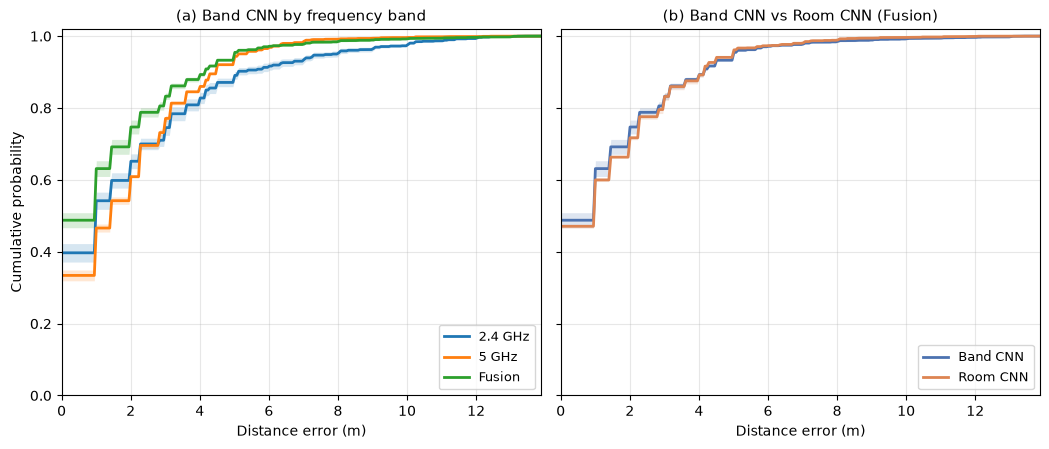

In [13]:
if has_block:
    plot_dl_cdf_comparison(
        all_cnn_predictions,
        split="block",
        seeds=SEEDS,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "cdf_comparison_band-vs-room_block.pdf",
        show=DISPLAY_PLOTS,
    )
else:
    print("Temporal Block plots skipped: the block split is not selected or unavailable.")

### LOVO Plots

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_comparison_band-vs-room_lovo.pdf.


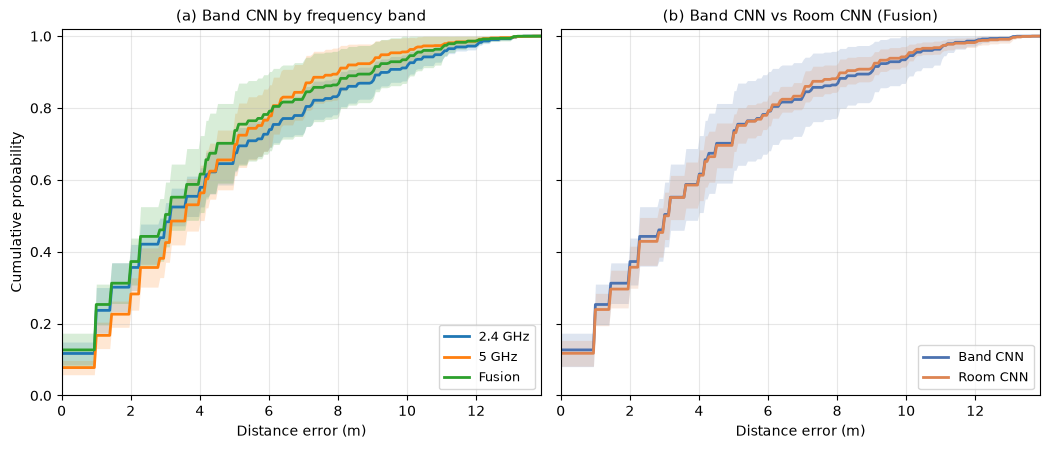

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/lovo_volunteer_variability_band-vs-room.pdf.


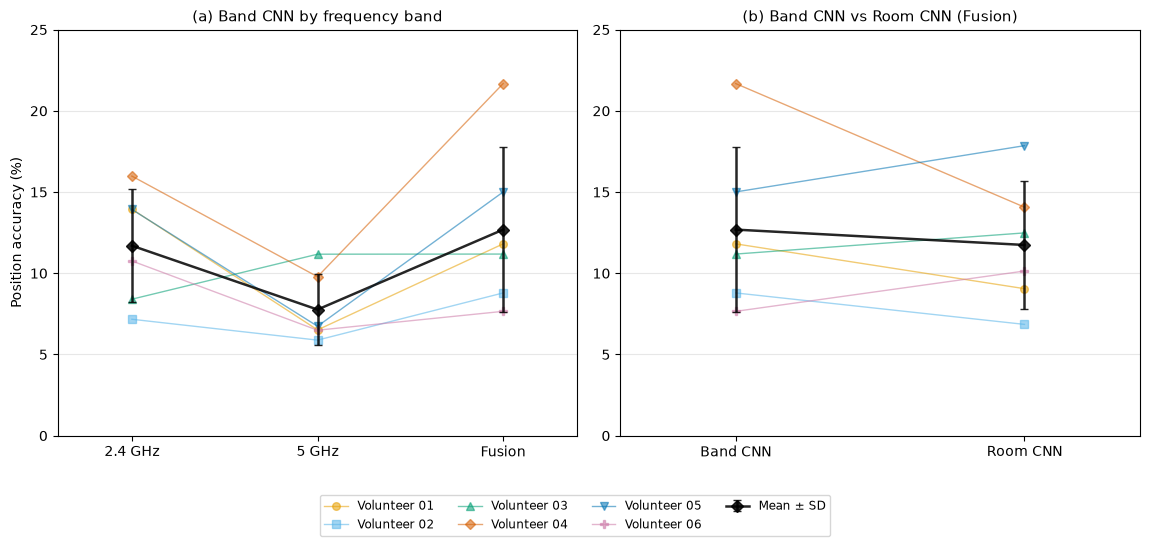

In [14]:
if has_lovo:
    plot_dl_cdf_comparison(
        all_cnn_predictions,
        split="lovo",
        seeds=SEEDS,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "cdf_comparison_band-vs-room_lovo.pdf",
        show=DISPLAY_PLOTS,
    )

    plot_dl_volunteer_variability(
        all_cnn_predictions,
        seeds=SEEDS,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "lovo_volunteer_variability_band-vs-room.pdf",
        show=DISPLAY_PLOTS,
    )
else:
    print("LOVO plots skipped: the LOVO split is not selected or unavailable.")

### Cross Session Plots

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_comparison_band-vs-room_cross_session.pdf.


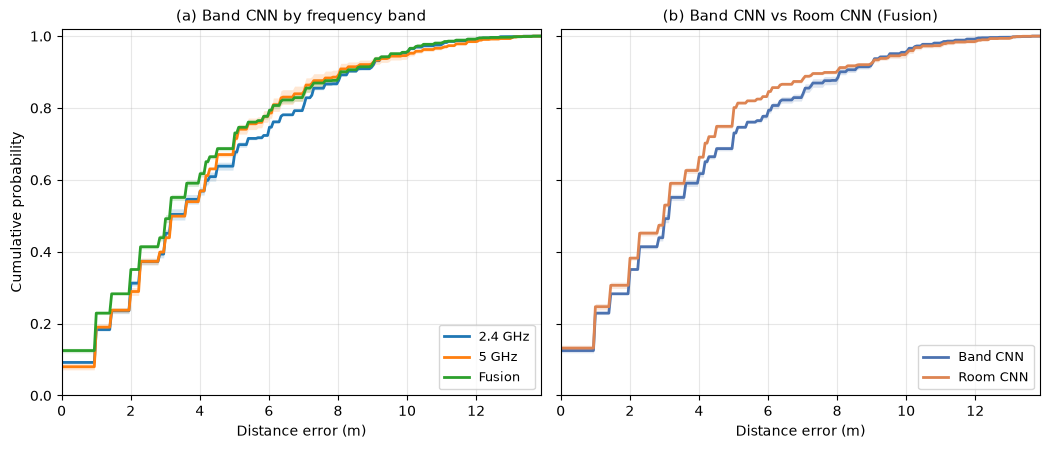

In [15]:
if has_cross_session:
    plot_dl_cdf_comparison(
        all_cnn_predictions,
        split="cross_session",
        seeds=SEEDS,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "cdf_comparison_band-vs-room_cross_session.pdf",
        show=DISPLAY_PLOTS,
    )
else:
    print("Cross Session plots skipped: the cross_session split is not selected or unavailable.")

### Temporal Block versus LOVO Plots

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/block_vs_lovo_band-vs-room_metrics.pdf.


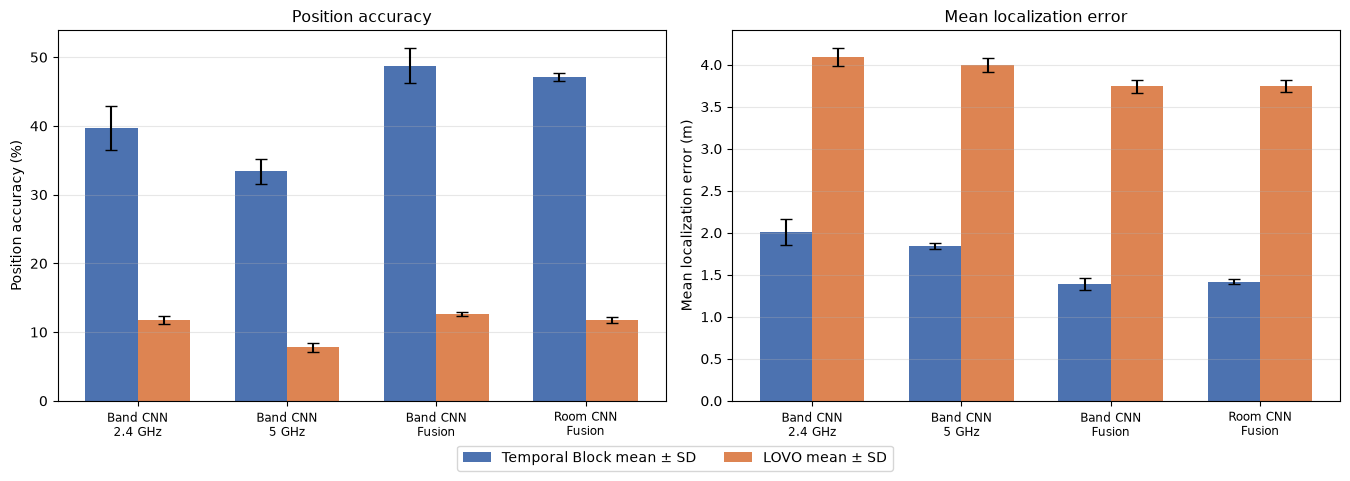

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/floor_plan_block_vs_lovo_band-cnn_fusion_block_accuracy.pdf.


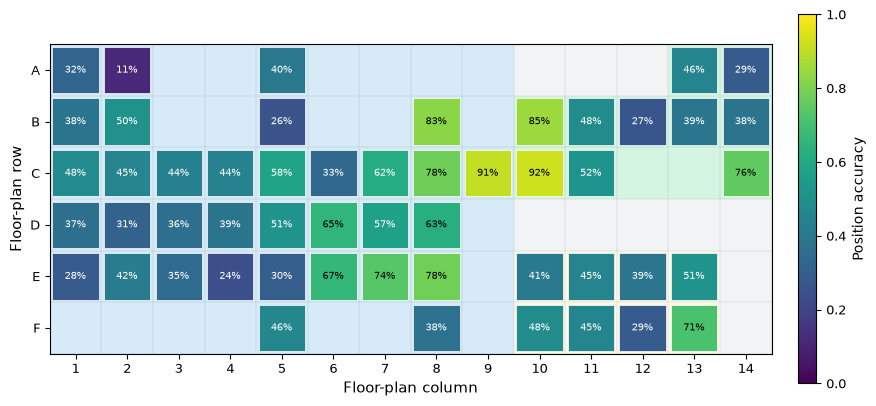

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/floor_plan_block_vs_lovo_band-cnn_fusion_lovo_accuracy.pdf.


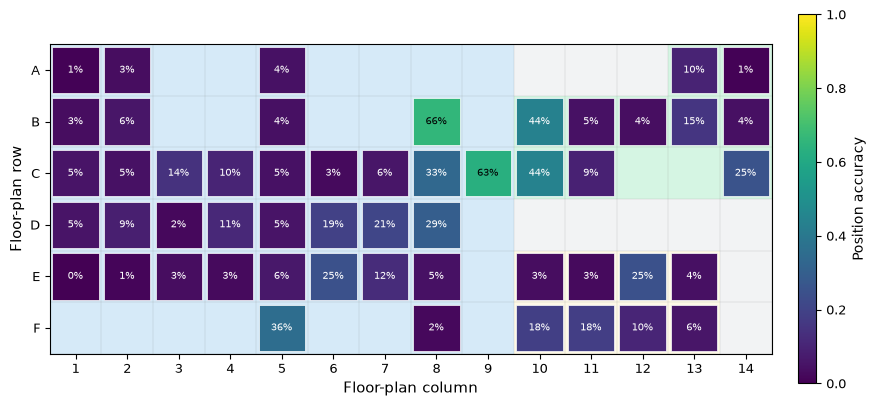

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/floor_plan_block_vs_lovo_band-cnn_fusion_accuracy_decrease.pdf.


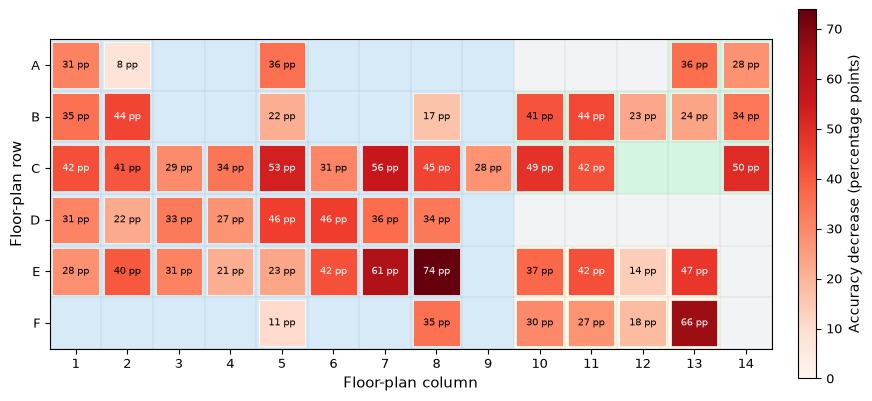

In [16]:
if has_block and has_lovo:
    plot_dl_block_vs_lovo_metrics(
        cnn_master_table,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "block_vs_lovo_band-vs-room_metrics.pdf",
        show=DISPLAY_PLOTS,
    )

    block_fusion_cnn = all_cnn_predictions.loc[
        (all_cnn_predictions["split_mode"] == "block")
        & (all_cnn_predictions["model"] == "CNN")
        & (all_cnn_predictions["dataset"] == "Fusion")
    ]
    lovo_fusion_cnn = all_cnn_predictions.loc[
        (all_cnn_predictions["split_mode"] == "lovo")
        & (all_cnn_predictions["model"] == "CNN")
        & (all_cnn_predictions["dataset"] == "Fusion")
    ]
    plot_dl_spatial_generalization(
        block_fusion_cnn,
        lovo_fusion_cnn,
        seeds=SEEDS,
        save_path=plots_dir / "floor_plan_block_vs_lovo_band-cnn_fusion.pdf",
        show=DISPLAY_PLOTS,
    )
else:
    print("Temporal Block vs LOVO plots skipped: both splits are required.")